## Formulación y entrenamiento de modelos

En esta sección se formulan y entrenan tres enfoques de modelado con el objetivo de capturar tanto la relación entre las variables estructurales de los inmuebles como su dependencia espacial:

1. **Geographically Weighted Regression (GWR)**  
2. **Random Forest con kriging sobre los residuos (Regression Kriging)**  
3. **Modelo autorregresivo espacial (SAR)**  

Los dos primeros modelos se evalúan en términos de desempeño predictivo y se analizan desde un punto de vista interpretativo, estudiando la importancia de las variables explicativas y la estructura que cada modelo logra capturar.

Dado que el modelo de *Regression Kriging* presenta un rendimiento superior, se utiliza para construir un mapa estimado del precio de un departamento promedio. Este ejercicio permite visualizar de manera intuitiva la información espacial que el modelo logra incorporar más allá de las covariables observadas.

Finalmente, todos los modelos se reentrenan utilizando el conjunto completo de datos. Sobre los residuos *in-sample* resultantes se aplican distintas técnicas de detección de outliers, bajo la hipótesis de que observaciones con residuos negativos extremos podrían corresponder a propiedades con precios atípicamente bajos respecto de lo esperado según el modelo. Este análisis resulta especialmente relevante si los modelos logran capturar adecuadamente la estructura espacial subyacente del mercado.


In [5]:
import folium
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
from skgstat import Variogram
import geopandas as gpd
from shapely.geometry import Point
import statsmodels.api as sm
import ast
from shapely.ops import unary_union
from pykrige.ok import OrdinaryKriging
from esda import G_Local
import matplotlib.pyplot as plt
from libpysal.weights import Kernel
import os
import sys
PROJECT_ROOT = os.path.abspath("..")  
if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)
sys.path.append(os.path.abspath("../models"))
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from esda.moran import Moran_Local
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from patsy import dmatrices
from pykrige.rk import RegressionKriging
from statsmodels.robust.scale import mad
from libpysal.weights import Kernel
from models.gwrmodel import GWRModel
from models.rfrkModel import RegressionKrigingModel
from models.sarModel import SpatialAutoregressiveModel
from models.modelEvaluator import ModelEvaluator
from models.spatialOutlierDetector import SpatialOutlierDetector
from models.strategies import Strategy



In [6]:
df = pd.read_csv("../storage/data/arg_venta_caba_processed.csv")

gdf = gpd.GeoDataFrame(
    df,
    geometry=gpd.points_from_xy(df.longitud, df.latitud),
    crs="EPSG:4326"
)
barrios = gpd.read_file("../barrios.geojson")


In [16]:

GWRmodel = GWRModel()
RFRKmodel = RegressionKrigingModel()
SARmodel = SpatialAutoregressiveModel()
features_gwr = [
    'area_m2_total',
    'area_m2_descubierta',
    'ambientes',
    'antiguedad',
    'expensas',
    'estado_num'
]

features_rfrk = [
    'area_m2_total',
    'area_m2_descubierta',
    'ambientes',
    'antiguedad',
    'expensas',
    'banos',
    'cocheras',
    'estado_num'
]

features_SAR = [
    'area_m2_total',
    'area_m2_descubierta',
    'ambientes',
    'antiguedad',
    'expensas',
    'banos',
    'cocheras',
    'estado_num'
]
features_for_models = [features_gwr, features_rfrk, features_SAR]

response = 'log_precio'

models = [GWRmodel, RFRKmodel, SARmodel]
metrics = {}
residuals_models = {}

gdf = gdf.to_crs(epsg=3857)

coords_tot   = np.column_stack([gdf.geometry.x,   gdf.geometry.y])


evaluator = ModelEvaluator()
for i in range(len(models)):
    model  = models[i]
    features = features_for_models[i]
    X_tot   = gdf[features]
    Y_tot   = gdf[response].to_numpy().reshape(-1,1)

    model.fit(X_tot, Y_tot, coords_tot)
    residuals_models[str(model.__class__.__name__)] = Y_tot - model.in_sample_predictions()
    


Model type                                                         Gaussian
Number of observations:                                                1740
Number of covariates:                                                     7

Global Regression Results
---------------------------------------------------------------------------
Residual sum of squares:                                            395.918
Log-likelihood:                                                   -1180.976
AIC:                                                               2375.953
AICc:                                                              2378.036
BIC:                                                             -12535.105
R2:                                                                   0.636
Adj. R2:                                                              0.634

Variable                              Est.         SE  t(Est/SE)    p-value
------------------------------- ---------- ---------- ------

In [17]:
print(SARmodel.summary())

REGRESSION RESULTS
------------------

SUMMARY OF OUTPUT: MAXIMUM LIKELIHOOD SPATIAL LAG (METHOD = FULL)
-----------------------------------------------------------------
Data set            :     unknown
Weights matrix      :     unknown
Dependent Variable  :           y                Number of Observations:        1740
Mean dependent var  :     11.3875                Number of Variables   :          10
S.D. dependent var  :      0.7906                Degrees of Freedom    :        1730
Pseudo R-squared    :      0.7643
Spatial Pseudo R-squared:  0.7044
Log likelihood      :   -833.5363
Sigma-square ML     :      0.1473                Akaike info criterion :    1687.073
S.E of regression   :      0.3838                Schwarz criterion     :    1741.689

------------------------------------------------------------------------------------
            Variable     Coefficient       Std.Error     z-Statistic     Probability
---------------------------------------------------------------

In [19]:
GWRmodel.summary()

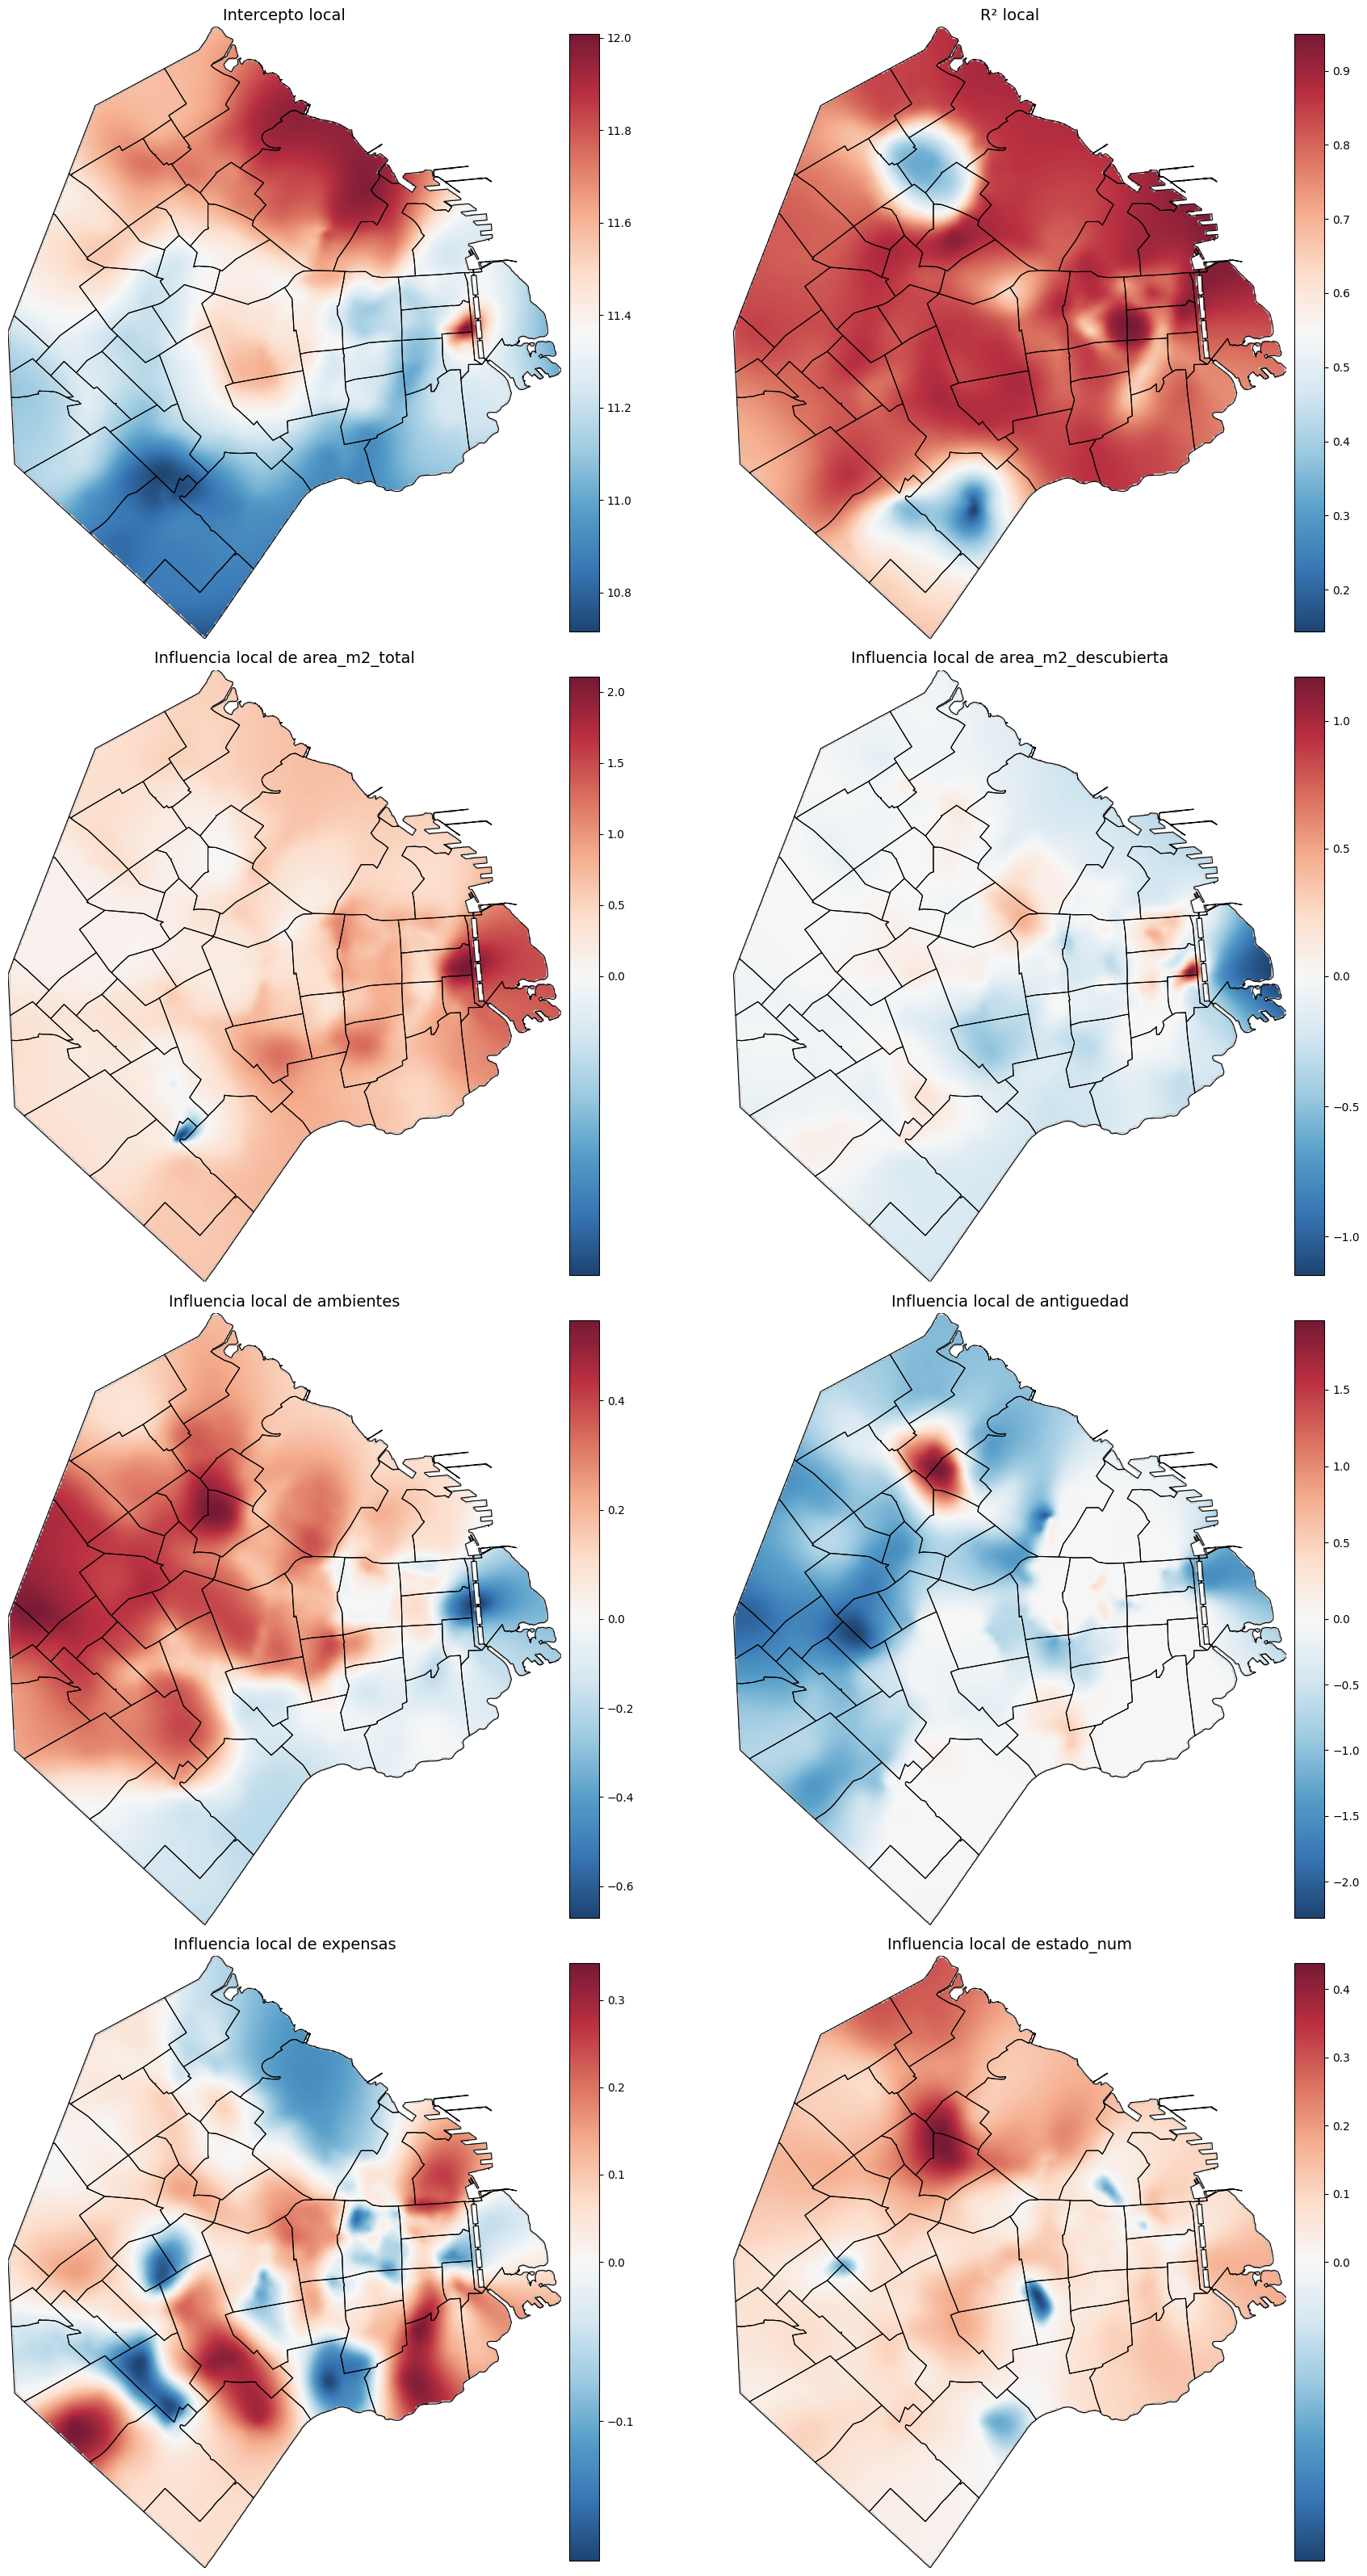

In [10]:
surfaces = GWRmodel.plot_gwr_surfaces(
    gdf=gdf.to_crs(epsg=3857),
    feature_names= features_gwr,
    barrios = barrios.to_crs(gdf.crs),
    grid_size=300,
    return_surfaces=True
)


In [11]:
pd.Series(
    RFRKmodel.feature_importances_(),
    index=features_rfrk
).sort_values(ascending=False)

area_m2_total          0.350725
banos                  0.178134
ambientes              0.117377
expensas               0.104915
antiguedad             0.082683
cocheras               0.068234
area_m2_descubierta    0.054168
estado_num             0.043764
dtype: float64

In [21]:
#Tomamos precio estimado para un departamento lo más standard posible en una grilla de zonas
#Con esto, hacemos un mapa con la estimación del precio por m2 en función de la ubicación
barrios = gpd.read_file("../barrios.geojson")
barrios = barrios.to_crs(gdf.crs)
caba_polygon = unary_union(barrios.geometry)

std_depto = {
    "area_m2_total": gdf["area_m2_total"].median(),
    "area_m2_descubierta": gdf["area_m2_descubierta"].median(),
    "ambientes": int(round(gdf["ambientes"].median())),
    "antiguedad": int(round(gdf["antiguedad"].median())),
    "expensas": gdf["expensas"].median(),
    "banos": int(round(gdf["banos"].median())),
    "cocheras": int(round(gdf["cocheras"].median())),
    "estado_num": int(round(gdf["estado_num"].median())),
}
xmin, ymin, xmax, ymax = caba_polygon.bounds
grid_size = 200

xs = np.linspace(xmin, xmax, grid_size)
ys = np.linspace(ymin, ymax, grid_size)

xx, yy = np.meshgrid(xs, ys)
coords_grid = np.column_stack([xx.ravel(), yy.ravel()])
gdf_grid = gpd.GeoDataFrame(
    geometry=[Point(xy) for xy in coords_grid],
    crs=gdf.crs
)
gdf_grid = gdf_grid[gdf_grid.within(caba_polygon)]
coords_grid = np.array([(p.x, p.y) for p in gdf_grid.geometry])
X_std_grid = pd.DataFrame(
    [std_depto] * len(coords_grid),
    columns=std_depto.keys()
)

y_pred_models = []
for i in range(len(models)):
    model  = models[i]
    features = features_for_models[i]
    X_std_grid_model = X_std_grid[features]
    y_pred = model.predict(X_std_grid_model, coords_grid)
    y_pred_models.append(y_pred)


    gdf_grid["precio_m2"] = y_pred / std_depto["area_m2_total"]
    fig, ax = plt.subplots(1, 1, figsize=(10, 10))

    gdf_grid.plot(
        column="precio_m2",
        ax=ax,
        cmap="viridis",
        markersize=5,
        legend=True
    )

    barrios.boundary.plot(ax=ax, color="black", linewidth=0.5)

    ax.set_title("Precio estimado por m² – Departamento estándar")
    ax.axis("off")

    plt.show()

print("Precio por m^2 estimado para un departamento con las siguientes caracteristica:")
for k, v in std_depto.items():
    print(f"  {k}: {v}")

IndexError: index 1904 is out of bounds for axis 0 with size 1740